In [ ]:
# Télécharger en ignorant la vérification du certificat
!wget --no-check-certificate -O eurosat.zip "https://madm.dfki.de/files/sentinel/EuroSAT.zip"

# Vérifier le type de fichier téléchargé
!file eurosat.zip

# Si le fichier semble correct (un fichier zip), l'extraire :
!unzip eurosat.zip -d .

# Vérifier le contenu du répertoire pour voir le dossier extrait
!ls

# Dans cet exemple, nous supposons que le dossier extrait s'appelle "EuroSAT".
# Si le dossier a un autre nom (par exemple "2750_EuroSAT"), modifie la variable data_dir en conséquence.
data_dir = "2750"

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: ./2750/SeaLake/SeaLake_1313.jpg  
  inflating: ./2750/SeaLake/SeaLake_263.jpg  
  inflating: ./2750/SeaLake/SeaLake_967.jpg  
  inflating: ./2750/SeaLake/SeaLake_515.jpg  
  inflating: ./2750/SeaLake/SeaLake_1465.jpg  
  inflating: ./2750/SeaLake/SeaLake_1817.jpg  
  inflating: ./2750/SeaLake/SeaLake_2902.jpg  
  inflating: ./2750/SeaLake/SeaLake_2570.jpg  
  inflating: ./2750/SeaLake/SeaLake_1004.jpg  
  inflating: ./2750/SeaLake/SeaLake_174.jpg  
  inflating: ./2750/SeaLake/SeaLake_2111.jpg  
  inflating: ./2750/SeaLake/SeaLake_2388.jpg  
  inflating: ./2750/SeaLake/SeaLake_1948.jpg  
  inflating: ./2750/SeaLake/SeaLake_838.jpg  
  inflating: ./2750/SeaLake/SeaLake_2738.jpg  
  inflating: ./2750/SeaLake/SeaLake_1999.jpg  
  inflating: ./2750/SeaLake/SeaLake_2359.jpg  
  inflating: ./2750/SeaLake/SeaLake_2660.jpg  
  inflating: ./2750/SeaLake/SeaLake_1775.jpg  
  inflating: ./2750/SeaLake/SeaLak

In [ ]:
!ls 2750


AnnualCrop  HerbaceousVegetation  Industrial  PermanentCrop  River
Forest	    Highway		  Pasture     Residential    SeaLake


Classes : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)
Epoch [1/20], Loss: 0.9274, Test Accuracy: 76.89%
Epoch [2/20], Loss: 0.5820, Test Accuracy: 82.48%
Epoch [3/20], Loss: 0.4851, Test Accuracy: 82.43%
Epoch [4/20], Loss: 0.4277, Test Accuracy: 85.28%
Epoch [5/20], Loss: 0.3474, Test Accuracy: 85.22%
Epoch

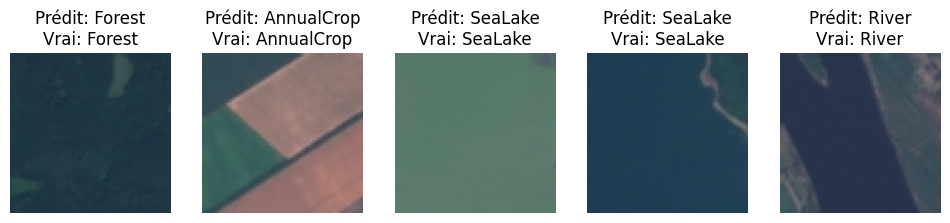

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 20
batch_size = 64
learning_rate = 0.001

# Chemin vers le dataset EuroSAT
data_dir = "2750"  #

# Transformations : redimensionnement et normalisation

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # valeurs souvent utilisées pour les images RGB
                         [0.229, 0.224, 0.225])
])

# Chargement du dataset avec ImageFolder
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Affichage des classes disponibles
classes = dataset.classes
print("Classes :", classes)

# Division du dataset en train et test (80% train, 20% test)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Définition d'un modèle CNN simple
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        # Convolution 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        # Convolution 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        # Max Pooling
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        # Fully Connected layers
        self.fc1 = nn.Linear(64 * 16 * 16, 256)  # Si images de 64x64 => après 2x2 pooling: 16x16
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))  # (B, 32, 64, 64)
        x = self.pool(x)                     # (B, 32, 32, 32)
        x = F.relu(self.bn2(self.conv2(x)))  # (B, 64, 32, 32)
        x = self.pool(x)                     # (B, 64, 16, 16)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

num_classes = len(classes)
model = SimpleCNN(num_classes).to(device)
print(model)

# Définition de la fonction de perte et de l'optimiseur
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Entraînement du modèle
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)

    # Évaluation sur le jeu de test
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total * 100
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%")

# Sauvegarde du modèle entraîné
torch.save(model.state_dict(), "satellite_model.pth")

# Affichage de quelques prédictions
model.eval()
import matplotlib.pyplot as plt
import numpy as np

# Prendre quelques images du jeu de test
images, labels = next(iter(test_loader))
images = images.to(device)
outputs = model(images)
_, preds = torch.max(outputs, 1)

# Afficheage de 5 images et leurs prédictions
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(1, 5, i+1)
    img = images[i].cpu().numpy().transpose((1, 2, 0))
    img = np.clip(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)
    plt.imshow(img)
    plt.title(f"Prédit: {classes[preds[i]]}\nVrai: {classes[labels[i]]}")
    plt.axis("off")
plt.show()
